# Extração de Descritores + Grade de Experimentos — RSNA Abdominal Trauma (G7)

**Marco 3 (Semana 3)** do TP1 — Baseline de Projeto de Pesquisa.

Este notebook cobre:
1. Extração das demais famílias de descritores (§4.2) — agora com **3 famílias no
   total**: intensidade (Semana 2), **textura (GLCM)** e **forma**.
2. Grade de experimentos **descritor × modelo**, com ≥3 modelos clássicos exigidos
   pelo §4.3: **SVM**, **Random Forest** e **Gradient Boosting** (além da Regressão
   Logística já treinada na Semana 2).
3. Validação cruzada com ajuste de hiperparâmetros (§4.4).
4. Estudo de ablação: comparação de desempenho por família de descritor isolada
   vs. combinada.
5. Consolidação de tabelas e ao menos uma figura para a seção de Resultados do
   artigo.

> Continuação direta dos notebooks da Semana 1 (EDA) e Semana 2 (pré-processamento
> + baseline). Mesma configuração de `DATA_DIR`, mesma semente (`SEED = 42`), mesma
> amostra (500 pacientes) e mesma partição treino/teste congelada.


In [1]:
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydicom
from scipy import ndimage as ndi
from scipy.stats import skew, kurtosis

from skimage.feature import graycomatrix, graycoprops
from skimage.measure import regionprops, label as sk_label

from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize, LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    roc_auc_score, average_precision_score, balanced_accuracy_score,
    f1_score, confusion_matrix, make_scorer,
)

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

%matplotlib inline

## 1. Configuração e carregamento da amostra/partição (reaproveitadas)

Mesma lógica das semanas anteriores: procura os arquivos primeiro na pasta de
trabalho local e, se este notebook estiver em sessão separada, dentro de
`/kaggle/input/` (pulando a pasta da competição, que é enorme).

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path("/kaggle/input/competitions/rsna-2023-abdominal-trauma-detection")
TRAIN_CSV = DATA_DIR / "train_2024.csv"
SERIES_META_CSV = DATA_DIR / "train_series_meta.csv"
IMAGES_DIR = DATA_DIR / "train_images"

train_df = pd.read_csv(TRAIN_CSV)
series_meta_df = pd.read_csv(SERIES_META_CSV)


def find_input_file(filename, search_root=Path("/kaggle/input")):
    """Procura um arquivo pelo nome dentro de /kaggle/input, pulando a pasta de
    dados da competição (centenas de GB de DICOM, nunca contém nossos CSVs)."""
    if not search_root.exists():
        return None
    for child in search_root.iterdir():
        if child.name == "competitions":
            continue
        matches = list(child.rglob(filename))
        if matches:
            return matches[0]
    return None


def load_cached_csv(filename):
    """Carrega um CSV já gerado em semana anterior: local, ou em /kaggle/input/."""
    local_path = Path(filename)
    if local_path.exists():
        return pd.read_csv(local_path)
    found = find_input_file(filename)
    if found is not None:
        df = pd.read_csv(found)
        df.to_csv(local_path, index=False)
        return df
    return None


sample_df = load_cached_csv("sample_patient_ids.csv")
split_df = load_cached_csv("train_test_split.csv")
intensity_features_df = load_cached_csv("intensity_features.csv")

assert sample_df is not None, "Amostra não encontrada — rode a Semana 1 antes."
assert split_df is not None, "Partição não encontrada — rode a Semana 2 antes."

print(f"Amostra: {len(sample_df)} pacientes | Partição: "
      f"{(split_df['split'] == 'train').sum()} treino / {(split_df['split'] == 'test').sum()} teste")
print("Features de intensidade (Semana 2) encontradas:", intensity_features_df is not None)
print("XGBoost disponível:", HAS_XGBOOST)


Amostra: 500 pacientes | Partição: 400 treino / 100 teste
Features de intensidade (Semana 2) encontradas: True
XGBoost disponível: True


## 2. Pipeline de pré-processamento (reaproveitado da Semana 2)

Mesmas funções: leitura DICOM → HU → janelamento → remoção de mesa/fundo →
redimensionamento. Reproduzidas aqui porque este notebook roda em sessão própria.

In [3]:
def dicom_to_hu(dcm):
    slope = float(getattr(dcm, "RescaleSlope", 1.0))
    intercept = float(getattr(dcm, "RescaleIntercept", 0.0))
    return dcm.pixel_array.astype(np.float32) * slope + intercept


def apply_window(hu_img, window_center=40, window_width=400):
    low = window_center - window_width / 2
    high = window_center + window_width / 2
    windowed = np.clip(hu_img, low, high)
    return (windowed - low) / (high - low)


def crop_body(img_01, hu_threshold_frac=0.02):
    mask = img_01 > hu_threshold_frac
    if not mask.any():
        return img_01
    labeled, n_components = ndi.label(mask)
    if n_components == 0:
        return img_01
    sizes = ndi.sum(mask, labeled, range(1, n_components + 1))
    largest_label = np.argmax(sizes) + 1
    body_mask = labeled == largest_label
    rows = np.any(body_mask, axis=1)
    cols = np.any(body_mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    cropped = img_01[rmin:rmax + 1, cmin:cmax + 1].copy()
    cropped_mask = body_mask[rmin:rmax + 1, cmin:cmax + 1]
    cropped[~cropped_mask] = 0.0
    return cropped


def resize_image(img, output_size=(256, 256)):
    zoom_factors = (output_size[0] / img.shape[0], output_size[1] / img.shape[1])
    return ndi.zoom(img, zoom_factors, order=1)


def preprocess_slice(dcm, window_center=40, window_width=400, output_size=(256, 256)):
    hu = dicom_to_hu(dcm)
    windowed = apply_window(hu, window_center, window_width)
    cropped = crop_body(windowed)
    resized = resize_image(cropped, output_size)
    return np.clip(resized, 0.0, 1.0)


def load_series_slices(patient_id, series_id, images_dir=IMAGES_DIR):
    series_dir = images_dir / str(patient_id) / str(series_id)
    dcm_paths = sorted(series_dir.glob("*.dcm"), key=lambda p: int(p.stem))
    return [pydicom.dcmread(p) for p in dcm_paths]


N_SLICES_PER_PATIENT = 5

def select_representative_slices(slices, n=N_SLICES_PER_PATIENT):
    if len(slices) <= n:
        return slices
    idx = np.linspace(0, len(slices) - 1, n).round().astype(int)
    return [slices[i] for i in idx]


## 3. Família 2 — Textura (GLCM)

Matriz de co-ocorrência de níveis de cinza (*gray-level co-occurrence matrix*),
descritor clássico de textura (Haralick), sugerido no enunciado (§4.2) e usado
nos artigos 3, 5 e 9 do fichamento. Quantizamos a imagem em 32 níveis de cinza
e calculamos as propriedades em 4 ângulos (0°, 45°, 90°, 135°), agregando pela
média entre ângulos — reduz sensibilidade à orientação do paciente na mesa.

In [4]:
GLCM_LEVELS = 32
GLCM_DISTANCES = [1]
GLCM_ANGLES = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]
GLCM_PROPS = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"]


def extract_texture_features(img):
    """Features de textura via GLCM sobre a região do corpo (imagem já em [0,1])."""
    quantized = (img * (GLCM_LEVELS - 1)).astype(np.uint8)
    glcm = graycomatrix(
        quantized, distances=GLCM_DISTANCES, angles=GLCM_ANGLES,
        levels=GLCM_LEVELS, symmetric=True, normed=True,
    )
    features = {}
    for prop in GLCM_PROPS:
        values = graycoprops(glcm, prop)  # shape: (n_distances, n_angles)
        features[f"glcm_{prop}_mean"] = values.mean()
        features[f"glcm_{prop}_std"] = values.std()
    return features


## 4. Família 3 — Forma

Descritores de forma (momentos de Hu, área, perímetro, excentricidade, solidez)
sobre a maior região de tecido mole conectada dentro do recorte de corpo —
usados por Wang et al. (2021) para o baço. **Limitação a declarar no artigo:**
como ainda não temos segmentação automática de órgão (ver `formulacao_problema.md`),
essa região é um *proxy* do tecido mole abdominal como um todo, não do órgão
específico — refinar isso com segmentação é um próximo passo natural.

In [5]:
def extract_shape_features(img, soft_tissue_threshold=0.15):
    """Features de forma sobre a maior região de tecido mole conectada."""
    mask = img > soft_tissue_threshold
    labeled = sk_label(mask)
    if labeled.max() == 0:
        return {
            "shape_area": 0.0, "shape_perimeter": 0.0, "shape_eccentricity": 0.0,
            "shape_solidity": 0.0, "shape_extent": 0.0,
            **{f"shape_hu{i}": 0.0 for i in range(7)},
        }
    props = regionprops(labeled)
    largest = max(props, key=lambda p: p.area)
    hu = largest.moments_hu
    return {
        "shape_area": largest.area,
        "shape_perimeter": largest.perimeter,
        "shape_eccentricity": largest.eccentricity,
        "shape_solidity": largest.solidity,
        "shape_extent": largest.extent,
        **{f"shape_hu{i}": hu[i] for i in range(7)},
    }


## 5. Extração para toda a amostra

Mesma estratégia de agregação 2.5D da Semana 2: para cada paciente, seleciona
cortes representativos, pré-processa cada um, extrai as duas novas famílias de
descritores e agrega por *pooling* de média.

In [6]:
def extract_patient_texture_shape(patient_id, series_meta_df, images_dir=IMAGES_DIR):
    series_rows = series_meta_df.loc[series_meta_df["patient_id"] == patient_id]
    if series_rows.empty:
        return None
    series_id = series_rows["series_id"].iloc[0]

    slices = load_series_slices(patient_id, series_id, images_dir)
    selected = select_representative_slices(slices)

    texture_rows, shape_rows = [], []
    for dcm in selected:
        processed = preprocess_slice(dcm)
        texture_rows.append(extract_texture_features(processed))
        shape_rows.append(extract_shape_features(processed))

    texture_agg = pd.DataFrame(texture_rows).mean().to_dict()
    shape_agg = pd.DataFrame(shape_rows).mean().to_dict()
    return {**texture_agg, **shape_agg}


In [7]:
# Extração para toda a amostra (a etapa mais demorada deste notebook).
texture_shape_rows = []
for pid in sample_df["patient_id"]:
    feats = extract_patient_texture_shape(pid, series_meta_df)
    if feats is not None:
        feats["patient_id"] = pid
        texture_shape_rows.append(feats)

texture_shape_df = pd.DataFrame(texture_shape_rows)
texture_shape_df.to_csv("texture_shape_features.csv", index=False)
print("Features de textura/forma extraídas para", len(texture_shape_df), "pacientes.")
texture_shape_df.head()


Features de textura/forma extraídas para 500 pacientes.


,glcm_contrast_mean,glcm_contrast_std,glcm_dissimilarity_mean,glcm_dissimilarity_std,glcm_homogeneity_mean,glcm_homogeneity_std,glcm_energy_mean,glcm_energy_std,glcm_correlation_mean,glcm_correlation_std,...,shape_solidity,shape_extent,shape_hu0,shape_hu1,shape_hu2,shape_hu3,shape_hu4,shape_hu5,shape_hu6,patient_id
0,8.585746,2.314633,1.541349,0.225698,0.587539,0.027490,0.259083,0.003278,0.927064,0.019669,...,0.843009,0.696488,0.203508,0.000148,0.000048,0.000065,8.430221e-09,-9.496988e-07,-2.449821e-09,55742
1,5.966096,1.641710,1.380719,0.196050,0.586928,0.028784,0.249487,0.004484,0.950722,0.013749,...,0.746933,0.623881,0.198359,0.003586,0.000089,0.000037,-2.941117e-09,-2.815940e-07,4.701833e-10,19574
2,8.571256,2.208760,1.609656,0.228970,0.569533,0.028727,0.255979,0.003921,0.932616,0.017354,...,0.802658,0.652022,0.201754,0.000185,0.000156,0.000045,1.662553e-08,7.255956e-07,1.616142e-09,42555
3,5.944152,1.739713,1.204847,0.192544,0.652769,0.028257,0.301711,0.003899,0.957465,0.012539,...,0.611638,0.485577,0.233139,0.001415,0.000231,0.000063,-5.181081e-09,1.836052e-06,-2.337469e-08,31845
4,5.728767,1.694570,1.268660,0.202441,0.621879,0.031058,0.250262,0.004543,0.946839,0.015664,...,0.836000,0.696260,0.196358,0.000236,0.000166,0.000040,5.478904e-09,7.544126e-07,-1.127211e-08,55663


## 6. Consolidação das 3 famílias de descritores + rótulos

Junta intensidade (Semana 2, reaproveitada), textura e forma (extraídas acima)
com os rótulos por órgão e a partição congelada.

In [8]:
assert intensity_features_df is not None, (
    "intensity_features.csv não encontrado — anexe a saída da Semana 2 como "
    "Input deste notebook, ou rode a extração de intensidade novamente."
)

organ_targets = {
    "bowel": ["bowel_healthy", "bowel_injury"],
    "extravasation": ["extravasation_healthy", "extravasation_injury"],
    "kidney": ["kidney_healthy", "kidney_low", "kidney_high"],
    "liver": ["liver_healthy", "liver_low", "liver_high"],
    "spleen": ["spleen_healthy", "spleen_low", "spleen_high"],
}

def get_target_label(row, cols):
    present_cols = [c for c in cols if c in row.index]
    active = [c for c in present_cols if row[c] == 1]
    return active[0] if active else present_cols[0]


all_features_df = intensity_features_df.merge(texture_shape_df, on="patient_id")
labeled_df = sample_df.merge(split_df, on="patient_id").merge(all_features_df, on="patient_id")

for organ, cols in organ_targets.items():
    labeled_df[f"{organ}_label"] = labeled_df.apply(lambda r: get_target_label(r, cols), axis=1)

labeled_df.to_csv("labeled_features_full.csv", index=False)

intensity_cols = [c for c in intensity_features_df.columns if c != "patient_id"]
texture_cols = [c for c in texture_shape_df.columns if c.startswith("glcm_")]
shape_cols = [c for c in texture_shape_df.columns if c.startswith("shape_")]

feature_sets = {
    "intensidade": intensity_cols,
    "textura": texture_cols,
    "forma": shape_cols,
    "combinado": intensity_cols + texture_cols + shape_cols,
}

print({name: len(cols) for name, cols in feature_sets.items()})


{'intensidade': 9, 'textura': 12, 'forma': 12, 'combinado': 33}


## 7. Métricas de avaliação (reaproveitadas da Semana 2)

Mesma função de métricas ampliadas — AUC-ROC, AUC-PR, sensibilidade,
especificidade, além de F1 e acurácia balanceada (§4.4: acurácia isolada não é
aceita).

In [9]:
def compute_extended_metrics(y_true, y_pred, y_proba, classes):
    result = {
        "balanced_accuracy": round(balanced_accuracy_score(y_true, y_pred), 3),
        "f1_macro": round(f1_score(y_true, y_pred, average="macro", zero_division=0), 3),
    }
    if len(classes) >= 2 and len(set(y_true)) >= 2:
        y_true_bin = label_binarize(y_true, classes=classes)
        if y_true_bin.shape[1] == 1:
            y_true_bin = np.hstack([1 - y_true_bin, y_true_bin])
            y_proba_use = y_proba[:, :2]
        else:
            y_proba_use = y_proba
    
        present_cols = [i for i in range(y_true_bin.shape[1]) if y_true_bin[:, i].sum() > 0]
        if len(present_cols) >= 1:
            try:
                result["auc_roc_macro"] = round(
                    roc_auc_score(y_true_bin[:, present_cols], y_proba_use[:, present_cols],
                                   average="macro", multi_class="ovr"), 3
                )
            except ValueError:
                result["auc_roc_macro"] = None
            try:
                result["auc_pr_macro"] = round(
                    average_precision_score(y_true_bin[:, present_cols], y_proba_use[:, present_cols],
                                             average="macro"), 3
                )
            except ValueError:
                result["auc_pr_macro"] = None
        else:
            result["auc_roc_macro"] = None
            result["auc_pr_macro"] = None

    cm = confusion_matrix(y_true, y_pred, labels=classes)
    sensitivities, specificities = [], []
    for i in range(len(classes)):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        sensitivities.append(tp / (tp + fn) if (tp + fn) > 0 else np.nan)
        specificities.append(tn / (tn + fp) if (tn + fp) > 0 else np.nan)
    result["sensitivity_mean"] = round(float(np.nanmean(sensitivities)), 3)
    result["specificity_mean"] = round(float(np.nanmean(specificities)), 3)
    return result


## 8. Modelos e grades de hiperparâmetros (§4.3)

≥3 modelos clássicos exigidos: **SVM** (kernel RBF), **Random Forest** e
**Gradient Boosting** (XGBoost quando disponível, senão o equivalente do
scikit-learn). Grades pequenas — a amostra é modesta (144 pacientes de treino),
então evitamos overfitting de hiperparâmetro com poucas opções por modelo.

In [10]:
def make_model_configs():
    configs = {
        "SVM": (
            SVC(probability=True, class_weight="balanced", random_state=SEED),
            {"svm__C": [0.1, 1, 10], "svm__kernel": ["rbf", "linear"]},
        ),
        "RandomForest": (
            RandomForestClassifier(class_weight="balanced_subsample", random_state=SEED),
            {"rf__n_estimators": [100, 300], "rf__max_depth": [None, 5, 10]},
        ),
    }
    if HAS_XGBOOST:
        configs["XGBoost"] = (
            XGBClassifier(
                random_state=SEED, eval_metric="mlogloss", use_label_encoder=False,
            ),
            {"xgb__n_estimators": [100, 300], "xgb__max_depth": [3, 5]},
        )
    else:
        configs["GradientBoosting"] = (
            GradientBoostingClassifier(random_state=SEED),
            {"gb__n_estimators": [100, 300], "gb__max_depth": [2, 3]},
        )
    return configs


def build_pipeline(model_name, base_estimator):
    step_name = {
        "SVM": "svm", "RandomForest": "rf", "XGBoost": "xgb", "GradientBoosting": "gb",
    }[model_name]
    return Pipeline([("scaler", StandardScaler()), (step_name, base_estimator)]), step_name


## 9. Grade de experimentos: descritor × modelo

Para cada órgão × família de descritor × modelo: `GridSearchCV` com validação
cruzada de 5 folds **só no treino** (o normalizador e os hiperparâmetros nunca
veem o teste — §4.4), depois avaliação final no teste congelado com as métricas
ampliadas. O desvio-padrão entre folds da validação cruzada é reportado junto
com a média, conforme a tabela do artigo exige.

Alvos com poucos exemplos de alguma classe no treino são pulados com aviso
(mesma situação da Semana 2, esperada dado o tamanho da amostra).

In [11]:
results_rows = []
balanced_acc_scorer = make_scorer(balanced_accuracy_score)

model_configs = make_model_configs()

for organ in organ_targets:
    label_col = f"{organ}_label"

    for family_name, cols in feature_sets.items():
        X_train = labeled_df.loc[labeled_df["split"] == "train", cols]
        y_train = labeled_df.loc[labeled_df["split"] == "train", label_col]
        X_test = labeled_df.loc[labeled_df["split"] == "test", cols]
        y_test = labeled_df.loc[labeled_df["split"] == "test", label_col]

        if y_train.nunique() < 2 or y_test.nunique() < 1:
            print(f"[{organ} | {family_name}] classes insuficientes no split — pulando.")
            continue

        # Número de dobras adaptado à classe minoritária deste alvo: evita
        # StratifiedKFold deixar algum fold sem nenhum exemplo de uma classe rara
        # (ex.: liver_high, só 4 pacientes no treino). Nunca menos que 2, nunca mais que 5.
        min_classe = min(Counter(y_train).values())
        n_splits_efetivo = max(2, min(5, min_classe))
        CV = StratifiedKFold(n_splits=n_splits_efetivo, shuffle=True, random_state=SEED)
        if n_splits_efetivo < 5:
            print(f"[{organ} | {family_name}] classe minoritária no treino tem "
                  f"{min_classe} exemplos — usando {n_splits_efetivo} dobras em vez de 5.")

        for model_name, (base_estimator, param_grid) in model_configs.items():
            pipeline, step_name = build_pipeline(model_name, base_estimator)

            if model_name == "XGBoost":
                le = LabelEncoder()
                y_train_fit = le.fit_transform(y_train)
                fit_params = {
                    f"{step_name}__sample_weight": compute_sample_weight("balanced", y_train_fit)
                }
            elif model_name == "RandomForest":
                y_train_fit = y_train
                fit_params = {
                    f"{step_name}__sample_weight": compute_sample_weight("balanced", y_train)
                }
            else:
                y_train_fit = y_train
                fit_params = {}

            try:
                search = GridSearchCV(
                    pipeline, param_grid, scoring=balanced_acc_scorer,
                    cv=CV, n_jobs=-1, error_score="raise",
                )
                search.fit(X_train, y_train_fit, **fit_params)
            except Exception as exc:
                print(f"[{organ} | {family_name} | {model_name}] falhou na CV "
                      f"({type(exc).__name__}: {exc}) — pulando.")
                continue

            cv_results = search.cv_results_
            best_idx = search.best_index_
            cv_mean = cv_results["mean_test_score"][best_idx]
            cv_std = cv_results["std_test_score"][best_idx]

            best_model = search.best_estimator_
            y_pred = best_model.predict(X_test)
            y_proba = best_model.predict_proba(X_test)

            if model_name == "XGBoost":
                y_pred = le.inverse_transform(y_pred)
                classes_for_metrics = list(le.classes_)
            else:
                classes_for_metrics = list(best_model.classes_)

            test_metrics = compute_extended_metrics(
                y_test, y_pred, y_proba, classes=classes_for_metrics
            )

            results_rows.append({
                "orgao": organ,
                "descritor": family_name,
                "modelo": model_name,
                "n_splits_cv": n_splits_efetivo,
                "balanced_accuracy_cv_mean": round(cv_mean, 3),
                "balanced_accuracy_cv_std": round(cv_std, 3),
                **{f"test_{k}": v for k, v in test_metrics.items()},
                "melhores_hiperparametros": str(search.best_params_),
            })

grid_results_df = pd.DataFrame(results_rows)
grid_results_df.to_csv("grid_experiments_results.csv", index=False)
print(f"{len(grid_results_df)} combinações órgão × descritor × modelo avaliadas.")
grid_results_df.head(10)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:45:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:45:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:45:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:45:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

[liver | intensidade] classe minoritária no treino tem 4 exemplos — usando 4 dobras em vez de 5.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:47:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:47:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:47:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:47:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

[liver | textura] classe minoritária no treino tem 4 exemplos — usando 4 dobras em vez de 5.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:47:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:47:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:47:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:47:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

...

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:47:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:47:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:47:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:47:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

[liver | combinado] classe minoritária no treino tem 4 exemplos — usando 4 dobras em vez de 5.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:47:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:47:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:47:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:47:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

60 combinações órgão × descritor × modelo avaliadas.


,orgao,descritor,modelo,n_splits_cv,balanced_accuracy_cv_mean,balanced_accuracy_cv_std,test_balanced_accuracy,test_f1_macro,test_auc_roc_macro,test_auc_pr_macro,test_sensitivity_mean,test_specificity_mean,melhores_hiperparametros
0,bowel,intensidade,SVM,5,0.679,0.174,0.724,0.344,0.668,0.517,0.724,0.724,"{'svm__C': 0.1, 'svm__kernel': 'linear'}"
1,bowel,intensidade,RandomForest,5,0.546,0.092,0.490,0.490,0.242,0.492,0.490,0.490,"{'rf__max_depth': 10, 'rf__n_estimators': 100}"
2,bowel,intensidade,XGBoost,5,0.499,0.003,0.500,0.495,0.847,0.639,0.500,0.500,"{'xgb__max_depth': 3, 'xgb__n_estimators': 300}"
3,bowel,textura,SVM,5,0.659,0.172,0.337,0.398,0.143,0.490,0.337,0.337,"{'svm__C': 1, 'svm__kernel': 'linear'}"
4,bowel,textura,RandomForest,5,0.540,0.113,0.418,0.451,0.347,0.500,0.418,0.418,"{'rf__max_depth': 5, 'rf__n_estimators': 300}"
5,bowel,textura,XGBoost,5,0.494,0.006,0.500,0.495,0.413,0.504,0.500,0.500,"{'xgb__max_depth': 5, 'xgb__n_estimators': 300}"
6,bowel,forma,SVM,5,0.619,0.135,0.531,0.379,0.505,0.509,0.531,0.531,"{'svm__C': 0.1, 'svm__kernel': 'rbf'}"
7,bowel,forma,RandomForest,5,0.505,0.083,0.403,0.441,0.214,0.491,0.403,0.403,"{'rf__max_depth': 5, 'rf__n_estimators': 300}"
8,bowel,forma,XGBoost,5,0.545,0.096,0.495,0.492,0.378,0.498,0.495,0.495,"{'xgb__max_depth': 3, 'xgb__n_estimators': 100}"
9,bowel,combinado,SVM,5,0.733,0.135,0.352,0.408,0.286,0.497,0.352,0.352,"{'svm__C': 0.1, 'svm__kernel': 'rbf'}"


## 10. Tabela comparativa consolidada (descritor × modelo)

Formato exigido pela Seção 5 do artigo: média ± desvio (da validação cruzada em
`balanced_accuracy`), por órgão, descritor e modelo.

In [12]:
summary_table = grid_results_df.copy()
summary_table["balanced_accuracy_cv"] = (
    summary_table["balanced_accuracy_cv_mean"].astype(str)
    + " ± " + summary_table["balanced_accuracy_cv_std"].astype(str)
)
summary_table = summary_table[[
    "orgao", "descritor", "modelo", "balanced_accuracy_cv",
    "test_balanced_accuracy", "test_auc_roc_macro", "test_auc_pr_macro",
    "test_sensitivity_mean", "test_specificity_mean",
]]
summary_table.to_csv("summary_table_descritor_modelo.csv", index=False)
summary_table


,orgao,descritor,modelo,balanced_accuracy_cv,test_balanced_accuracy,test_auc_roc_macro,test_auc_pr_macro,test_sensitivity_mean,test_specificity_mean
0,bowel,intensidade,SVM,0.679 ± 0.174,0.724,0.668,0.517,0.724,0.724
1,bowel,intensidade,RandomForest,0.546 ± 0.092,0.490,0.242,0.492,0.490,0.490
2,bowel,intensidade,XGBoost,0.499 ± 0.003,0.500,0.847,0.639,0.500,0.500
3,bowel,textura,SVM,0.659 ± 0.172,0.337,0.143,0.490,0.337,0.337
4,bowel,textura,RandomForest,0.54 ± 0.113,0.418,0.347,0.500,0.418,0.418
5,bowel,textura,XGBoost,0.494 ± 0.006,0.500,0.413,0.504,0.500,0.500
6,bowel,forma,SVM,0.619 ± 0.135,0.531,0.505,0.509,0.531,0.531
7,bowel,forma,RandomForest,0.505 ± 0.083,0.403,0.214,0.491,0.403,0.403
8,bowel,forma,XGBoost,0.545 ± 0.096,0.495,0.378,0.498,0.495,0.495
9,bowel,combinado,SVM,0.733 ± 0.135,0.352,0.286,0.497,0.352,0.352


## 11. Melhor combinação por órgão + comparação com baseline trivial e Semana 2

Identifica a melhor combinação descritor × modelo por órgão (por
`test_balanced_accuracy`) e junta com os resultados de baseline trivial e do
primeiro modelo (Regressão Logística + intensidade) da Semana 2, quando
disponíveis, para a comparação explícita exigida pela Seção 5 do artigo.

In [13]:
best_per_organ = (
    grid_results_df.sort_values("balanced_accuracy_cv_mean", ascending=False)
    .groupby("orgao")
    .first()
    .reset_index()
)
best_per_organ.to_csv("best_combination_per_organ.csv", index=False)

baseline_df = load_cached_csv("baseline_trivial_results.csv")
first_model_df = load_cached_csv("first_model_results.csv")

comparison_rows = []
for _, row in best_per_organ.iterrows():
    organ = row["orgao"]
    entry = {
        "orgao": organ,
        "baseline_trivial_bal_acc": None,
        "logreg_intensidade_bal_acc (Semana 2)": None,
        "melhor_combo_descritor_modelo": f"{row['descritor']} + {row['modelo']}",
        "melhor_combo_cv_mean": row["balanced_accuracy_cv_mean"],
        "melhor_combo_cv_std": row["balanced_accuracy_cv_std"],
        "melhor_combo_test_bal_acc": row["test_balanced_accuracy"],
    }
    if baseline_df is not None:
        match = baseline_df.loc[baseline_df["orgao"] == organ, "balanced_accuracy"]
        if not match.empty:
            entry["baseline_trivial_bal_acc"] = match.iloc[0]
    if first_model_df is not None:
        match = first_model_df.loc[first_model_df["orgao"] == organ, "balanced_accuracy"]
        if not match.empty:
            entry["logreg_intensidade_bal_acc (Semana 2)"] = match.iloc[0]
    comparison_rows.append(entry)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv("comparison_baseline_vs_best.csv", index=False)
comparison_df

,orgao,baseline_trivial_bal_acc,logreg_intensidade_bal_acc (Semana 2),melhor_combo_descritor_modelo,melhor_combo_cv_mean,melhor_combo_cv_std,melhor_combo_test_bal_acc
0,bowel,0.500,0.556,combinado + SVM,0.733,0.135,0.352
1,extravasation,0.500,0.550,intensidade + SVM,0.599,0.093,0.478
2,kidney,0.333,0.696,combinado + SVM,0.488,0.125,0.780
3,liver,0.333,0.330,textura + SVM,0.459,0.134,0.356
4,spleen,0.333,0.250,intensidade + SVM,0.478,0.079,0.186


## 12. Estudo de ablação: qual família de descritor mais contribui?

Compara o desempenho médio (entre modelos) de cada família isolada
(`intensidade`, `textura`, `forma`) contra a combinação de todas
(`combinado`), por órgão — responde à pergunta "qual etapa do pipeline mais
contribui?" pedida no cronograma da Semana 3.

In [14]:
ablation_df = (
    grid_results_df.groupby(["orgao", "descritor"])["test_balanced_accuracy"]
    .mean()
    .reset_index()
    .pivot(index="orgao", columns="descritor", values="test_balanced_accuracy")
)
ablation_df.to_csv("ablation_by_descriptor.csv")
ablation_df


descritor,combinado,forma,intensidade,textura
orgao,,,,
bowel,0.447333,0.476333,0.571333,0.418333
extravasation,0.499667,0.537000,0.492667,0.470000
kidney,0.472667,0.473333,0.300000,0.454000
liver,0.417333,0.397667,0.396333,0.324667
spleen,0.394667,0.366667,0.288333,0.379333


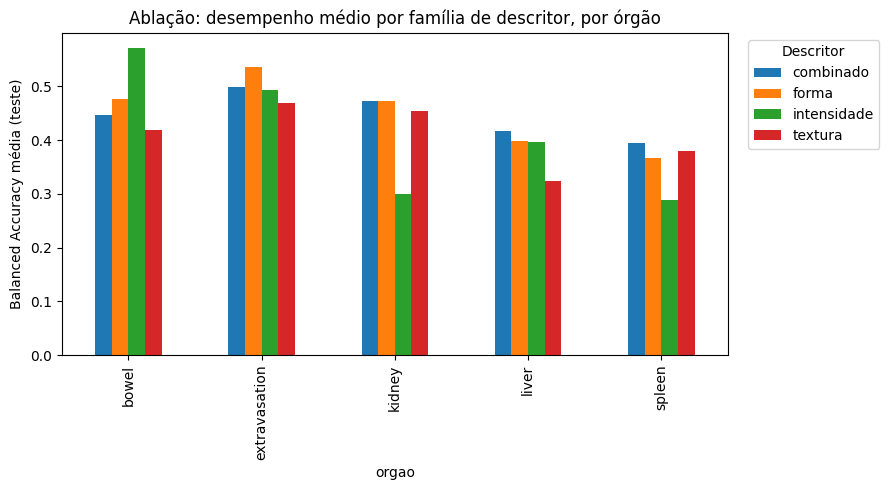

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
ablation_df.plot(kind="bar", ax=ax)
ax.set_ylabel("Balanced Accuracy média (teste)")
ax.set_title("Ablação: desempenho médio por família de descritor, por órgão")
ax.legend(title="Descritor", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("ablation_chart.png", dpi=150)
plt.show()


## 13. Figura para o artigo: importância de características (Random Forest)

Uma das opções de figura sugeridas pela Seção 5 do enunciado. Mostra, para o
órgão com melhor desempenho na combinação `combinado + RandomForest` (quando
disponível), quais descritores mais pesaram na decisão do modelo — direto para
a discussão de quais famílias carregam sinal clínico relevante (pergunta do
enunciado, Seção 1).

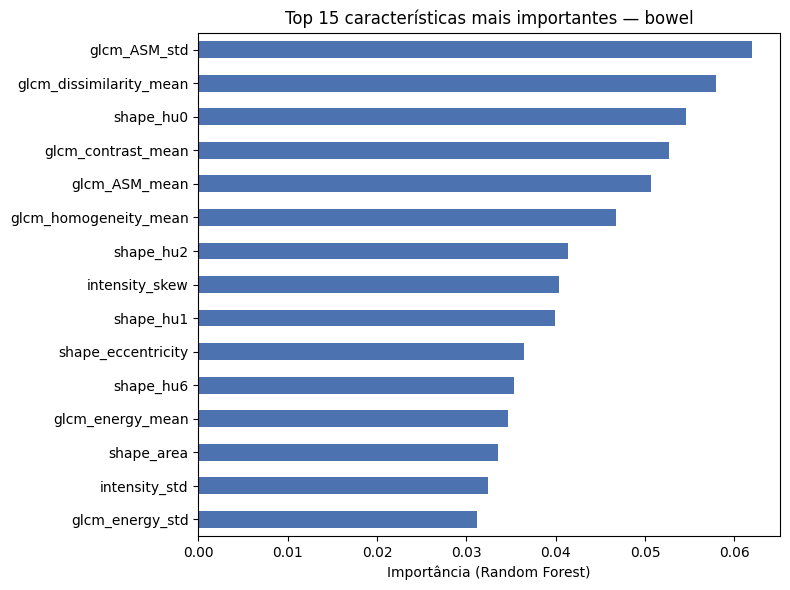

In [16]:
rf_rows = grid_results_df[
    (grid_results_df["modelo"] == "RandomForest") & (grid_results_df["descritor"] == "combinado")
]

if not rf_rows.empty:
    target_row = rf_rows.sort_values("test_balanced_accuracy", ascending=False).iloc[0]
    organ = target_row["orgao"]
    label_col = f"{organ}_label"
    cols = feature_sets["combinado"]

    X_train = labeled_df.loc[labeled_df["split"] == "train", cols]
    y_train = labeled_df.loc[labeled_df["split"] == "train", label_col]

    rf_final = RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=SEED
    )
    rf_final.fit(StandardScaler().fit_transform(X_train), y_train)

    importances = pd.Series(rf_final.feature_importances_, index=cols).sort_values(ascending=False)
    top_n = importances.head(15)

    fig, ax = plt.subplots(figsize=(8, 6))
    top_n[::-1].plot(kind="barh", ax=ax, color="#4C72B0")
    ax.set_xlabel("Importância (Random Forest)")
    ax.set_title(f"Top 15 características mais importantes — {organ}")
    plt.tight_layout()
    plt.savefig("feature_importance_top15.png", dpi=150)
    plt.show()
else:
    print("Nenhuma combinação combinado + RandomForest disponível para plotar "
          "(verifique se algum órgão foi pulado por classes insuficientes).")


Usando: bowel | intensidade | RandomForest | {'rf__max_depth': 10, 'rf__n_estimators': 100} (balanced_accuracy CV = 0.546, teste = 0.49)


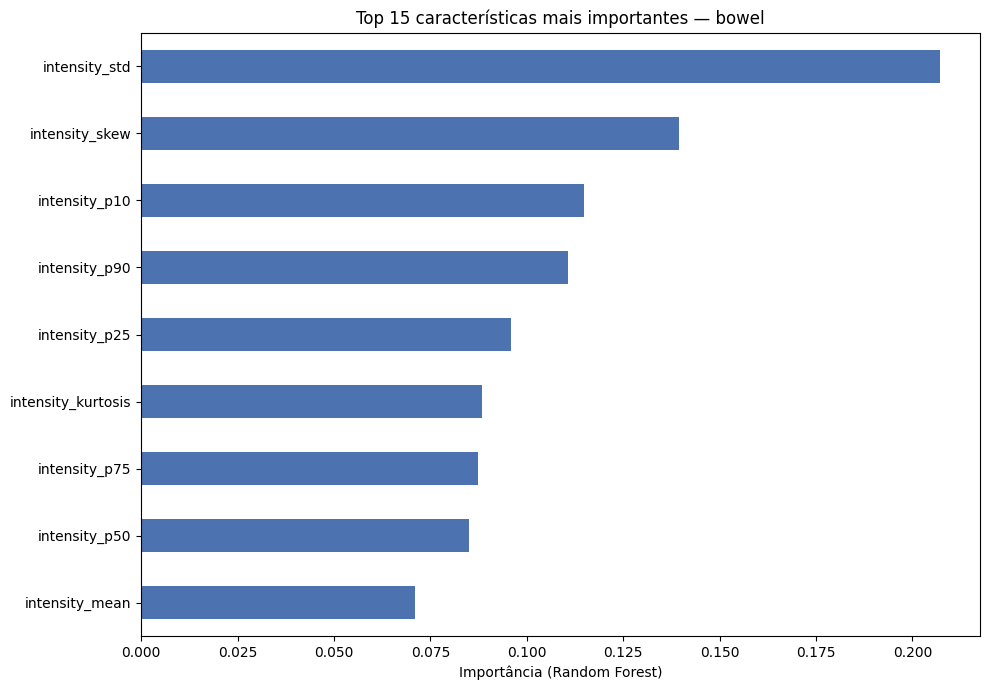

In [17]:
import ast

# Busca na grade completa, não só nas vencedoras por órgão — e por CV, não por teste
grid_df_fi = pd.read_csv("grid_experiments_results.csv")
labeled_df_fi = pd.read_csv("labeled_features_full.csv")

rf_rows = grid_df_fi[grid_df_fi["modelo"] == "RandomForest"]
if rf_rows.empty:
    raise RuntimeError("Nenhuma linha de RandomForest encontrada em grid_experiments_results.csv")

best_rf_row = rf_rows.sort_values("balanced_accuracy_cv_mean", ascending=False).iloc[0]

organ = best_rf_row["orgao"]
descritor = best_rf_row["descritor"]
hiperparametros = ast.literal_eval(best_rf_row["melhores_hiperparametros"])
print(f"Usando: {organ} | {descritor} | RandomForest | {hiperparametros} "
      f"(balanced_accuracy CV = {best_rf_row['balanced_accuracy_cv_mean']}, "
      f"teste = {best_rf_row['test_balanced_accuracy']})")

feature_sets_fi = {
    "intensidade": [c for c in labeled_df_fi.columns if c.startswith("intensity_")],
    "textura": [c for c in labeled_df_fi.columns if c.startswith("glcm_")],
    "forma": [c for c in labeled_df_fi.columns if c.startswith("shape_")],
}
feature_sets_fi["combinado"] = (
    feature_sets_fi["intensidade"] + feature_sets_fi["textura"] + feature_sets_fi["forma"]
)

cols = feature_sets_fi[descritor]
label_col = f"{organ}_label"

X_train = labeled_df_fi.loc[labeled_df_fi["split"] == "train", cols]
y_train = labeled_df_fi.loc[labeled_df_fi["split"] == "train", label_col]

rf = RandomForestClassifier(
    class_weight="balanced_subsample",
    random_state=SEED,
    n_estimators=hiperparametros["rf__n_estimators"],
    max_depth=hiperparametros["rf__max_depth"],
)
pipeline = Pipeline([("scaler", StandardScaler()), ("rf", rf)])
pipeline.fit(X_train, y_train, rf__sample_weight=compute_sample_weight("balanced", y_train))

importances = pd.Series(pipeline.named_steps["rf"].feature_importances_, index=cols)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
top15.sort_values().plot(kind="barh", color="#4C72B0")
plt.xlabel("Importância (Random Forest)")
plt.title(f"Top 15 características mais importantes — {organ}")
plt.tight_layout()
plt.savefig("feature_importance_top15_2.png", dpi=150)
plt.show()

## 14. Próximos passos (Semana 4)

- Análise de erro qualitativa: casos difíceis, hipóteses de causa (usar a matriz
  de confusão do melhor modelo por órgão).
- Redigir Resultados e Conclusão do artigo com base nas tabelas geradas aqui
  (`summary_table_descritor_modelo.csv`, `comparison_baseline_vs_best.csv`,
  `ablation_by_descriptor.csv`).
- Ajustar ao limite de 4 páginas.
- Testar reprodutibilidade em ambiente limpo (novo notebook Kaggle, seguindo só
  o README).

Artefatos gerados aqui, para subir em `outputs/` no repositório:
`texture_shape_features.csv`, `labeled_features_full.csv`,
`grid_experiments_results.csv`, `summary_table_descritor_modelo.csv`,
`best_combination_per_organ.csv`, `comparison_baseline_vs_best.csv`,
`ablation_by_descriptor.csv`, `ablation_chart.png`,
`feature_importance_top15.png`.